# LLM-as-judge consistency visualizations
Quick plots to inspect agreement across judges for one evaluated model. Swap `MODEL_DIR`, `JUDGE_NAMES`, `SPLIT`, and `DIMENSION` as needed; all plots refresh off those toggles.

In [1]:
from pathlib import Path
import json
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


# claude_opus_4_5_20251101_FC
# claude_sonnet_4_5_20250929_FC
# gemini_3_flash_FC
# kimi_k2_0905_preview_FC

# Base config — change freely
BASE_SCORE_DIR = "<PROJECT_ROOT>/Desktop/Desktop - ADUAED19365LPMX/Agent_IX_Personalization/gorilla/berkeley-function-call-leaderboard/LLM_as_judge_score"
MODEL_DIR = "kimi_k2_0905_preview_FC"  # evaluated model dir under each judge
JUDGE_NAMES = [
    "anthropic_claude-opus-4.5",
    "anthropic_claude-sonnet-4.5",
    "google_gemini-3-flash-preview",
    "moonshotai_kimi-k2-0905",
]
SPLIT = "no_personalization"  # or "personalization" or "no_personalization"
PERSONA_FILTER = []  # e.g., ["chain_parallel", "error_discovery_detail"]; empty => all personas
DIMENSION = "overall_user_experience"  # pick after loading if unsure

# Plot controls
MAX_SAMPLE_PLOTS = 6  # how many sample plots to emit
SAMPLE_INDEX = 0  # int to pick a specific sample by sorted order; set to None to skip
SAMPLE_KEYS_OVERRIDE = []  # manually list sample_keys (persona/test_id) to plot; empty => auto first N

sns.set_theme(style="whitegrid")


## Helpers
Lightweight loaders + plotting helpers to keep the rest of the notebook short.

In [2]:
def load_judge_scores(base_score_dir: str, judge_names, model_dir: str, split: str, personas=None) -> pd.DataFrame:
    """Return tidy frame with columns: sample_id, persona, judge, dimension, score."""
    personas = set(personas or [])
    rows = []
    base_path = Path(base_score_dir)

    for judge in judge_names:
        judge_dir = base_path / judge / model_dir / split
        if not judge_dir.exists():
            warnings.warn(f"Missing directory for judge {judge}: {judge_dir}")
            continue

        for persona_dir in sorted(p for p in judge_dir.iterdir() if p.is_dir()):
            persona = persona_dir.name
            if personas and persona not in personas:
                continue
            for fp in persona_dir.glob("*_judge.json"):
                try:
                    payload = json.loads(fp.read_text())
                except Exception as exc:  # pragma: no cover - interactive guard
                    warnings.warn(f"Failed to parse {fp.name} for {judge}: {exc}")
                    continue

                dims = (payload.get("parsed") or {}).get("dimensions") or {}
                test_id = payload.get("test_id") or fp.stem.replace("_judge", "")

                for dim_name, dim_content in dims.items():
                    score = dim_content.get("score")
                    if score is None:
                        continue
                    rows.append(
                        {
                            "sample_id": test_id,
                            "persona": persona,
                            "judge": judge,
                            "dimension": dim_name,
                            "score": score,
                            "file": str(fp),
                        }
                    )

    df = pd.DataFrame(rows)
    if not df.empty:
        df["sample_key"] = df["persona"].astype(str) + "/" + df["sample_id"].astype(str)
    return df


def pivot_dimension(df: pd.DataFrame, dimension: str) -> pd.DataFrame:
    """Pivot to sample_key x judge for a single dimension; drop rows missing any judge."""
    sub = df[df["dimension"] == dimension]
    wide = sub.pivot_table(index="sample_key", columns="judge", values="score", aggfunc="first")
    wide = wide.dropna()
    return wide


def sample_stats(wide: pd.DataFrame) -> pd.DataFrame:
    stats = wide.copy()
    stats["mean"] = wide.mean(axis=1)
    stats["std"] = wide.std(axis=1)
    stats["range"] = wide.max(axis=1) - wide.min(axis=1)
    return stats


def plot_radial_scatter(sample_key: str, series: pd.Series, dimension: str, ax=None):
    judges = list(series.index)
    scores = series.values.astype(float)
    angles = np.linspace(0, 2 * np.pi, len(judges), endpoint=False)
    x = scores * np.cos(angles)
    y = scores * np.sin(angles)

    ax = ax or plt.gca()
    ax.scatter(x, y, s=120, color="#1f77b4", label="Judge score")
    ax.scatter([x.mean()], [y.mean()], color="crimson", marker="x", s=140, label="Centroid")

    for judge, score, xi, yi in zip(judges, scores, x, y):
        ax.text(xi, yi, f"{judge}\n{score:.1f}", ha="center", va="center", fontsize=8)

    r_max = max(5, scores.max() + 0.75)
    ax.set_xlim(-r_max, r_max)
    ax.set_ylim(-r_max, r_max)
    ax.axhline(0, color="#cccccc", lw=0.7)
    ax.axvline(0, color="#cccccc", lw=0.7)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect("equal", "box")
    ax.set_title(f"{sample_key}\n{dimension}")
    ax.legend(loc="upper right", frameon=False)
    return ax


def zscore_by_judge(df: pd.DataFrame, score_col: str = "score", new_col: str = "score_z") -> pd.DataFrame:
    """Add a z-scored column per judge; judges with zero variance get 0."""
    df = df.copy()
    def _z(series):
        std = series.std(ddof=0)
        if std == 0 or pd.isna(std):
            return series*0
        return (series - series.mean()) / std
    df[new_col] = df.groupby("judge")[score_col].transform(_z)
    return df


In [3]:
import math

def kendalls_w(wide_df):
    """Kendall's W for judge agreement. wide_df: rows=samples, cols=judges."""
    if wide_df.empty or wide_df.shape[1] < 2:
        return math.nan
    ranks = wide_df.rank(axis=0, method="average")
    m = ranks.shape[1]
    n = ranks.shape[0]
    R = ranks.sum(axis=1)
    R_bar = R.mean()
    S = ((R - R_bar) ** 2).sum()
    T_sum = 0
    for col in ranks.columns:
        counts = ranks[col].value_counts()
        T_sum += (counts.pow(3) - counts).sum() / 12.0
    denom = m**2 * (n**3 - n) - m * T_sum
    return float(0 if denom == 0 else (12 * S) / denom)


def icc_oneway(wide_df):
    """ICC(1,1) one-way random effects; rows=targets, cols=judges."""
    if wide_df.empty or wide_df.shape[1] < 2:
        return math.nan
    n, k = wide_df.shape
    grand_mean = wide_df.values.mean()
    ms_between_targets = k * ((wide_df.mean(axis=1) - grand_mean) ** 2).sum() / (n - 1)
    ms_within = (wide_df.subtract(wide_df.mean(axis=1), axis=0) ** 2).sum().sum() / (n * (k - 1))
    denom = ms_between_targets + (k - 1) * ms_within
    return float(0 if denom == 0 else (ms_between_targets - ms_within) / denom)


def icc_two_way_mixed(wide_df):
    """ICC(3,1) two-way mixed, consistency; judges treated as fixed."""
    if wide_df.empty or wide_df.shape[1] < 2:
        return math.nan
    n, k = wide_df.shape
    grand_mean = wide_df.values.mean()
    row_means = wide_df.mean(axis=1)
    col_means = wide_df.mean(axis=0)

    ms_rows = k * ((row_means - grand_mean) ** 2).sum() / (n - 1)
    ms_cols = n * ((col_means - grand_mean) ** 2).sum() / (k - 1)
    residual = wide_df.subtract(row_means, axis=0)
    residual = residual.subtract(col_means - grand_mean, axis=1)
    ms_error = (residual ** 2).sum().sum() / ((n - 1) * (k - 1))

    denom = ms_rows + (k - 1) * ms_error
    return float(0 if denom == 0 else (ms_rows - ms_error) / denom)


def cronbach_alpha(wide_df):
    """Cronbach's alpha treating judges as items."""
    if wide_df.empty or wide_df.shape[1] < 2:
        return math.nan
    k = wide_df.shape[1]
    item_vars = wide_df.var(axis=0, ddof=1)
    total_var = wide_df.sum(axis=1).var(ddof=1)
    if total_var == 0:
        return math.nan
    return float((k / (k - 1)) * (1 - item_vars.sum() / total_var))


## Load data
Loads all judge JSONs into a tidy frame, then pivots for the chosen dimension.

In [4]:
df = load_judge_scores(
    base_score_dir=BASE_SCORE_DIR,
    judge_names=JUDGE_NAMES,
    model_dir=MODEL_DIR,
    split=SPLIT,
    personas=PERSONA_FILTER,
)
print(f"Loaded {len(df):,} rows from {df['judge'].nunique()} judges and {df['sample_key'].nunique()} samples.")

available_dimensions = sorted(df["dimension"].unique()) if not df.empty else []
if not available_dimensions:
    raise ValueError("No dimensions found; check paths/config.")

if DIMENSION not in available_dimensions:
    DIMENSION = available_dimensions[0]
    print(f"DIMENSION not found; defaulting to {DIMENSION}")
else:
    print(f"Using DIMENSION={DIMENSION}")

print("Dimensions:", available_dimensions)


Loaded 8,500 rows from 4 judges and 266 samples.
Using DIMENSION=overall_user_experience
Dimensions: ['commitment_consistency', 'initiative_timing', 'intent_alignment_drift', 'interaction_coherence', 'interaction_efficiency', 'interaction_preference_alignment', 'overall_user_experience', 'user_cognitive_load_trajectory']


## Score standardization (per judge)
Z-score each judge's scores to remove level bias before computing agreement metrics.

In [5]:
df_z = zscore_by_judge(df, score_col="score", new_col="score_z")
judge_stats = df_z.groupby("judge")["score_z"].agg(["mean", "std"])
print("Per-judge z-score mean/std (should be ~0/1):")
print(judge_stats)


Per-judge z-score mean/std (should be ~0/1):
                                       mean       std
judge                                                
anthropic_claude-opus-4.5      1.570903e-16  1.000235
anthropic_claude-sonnet-4.5    6.166746e-17  1.000235
google_gemini-3-flash-preview -9.243155e-18  1.000235
moonshotai_kimi-k2-0905        1.911177e-16  1.000236


In [6]:
wide = pivot_dimension(df, DIMENSION)
if wide.empty:
    raise ValueError(f"No complete rows for dimension {DIMENSION}; check data availability.")

stats = sample_stats(wide)
sample_keys = wide.index.to_list()
print(f"Pivoted shape: {wide.shape}, sample_keys={len(sample_keys)}")


Pivoted shape: (266, 4), sample_keys=266


In [7]:
wide_z = df_z[df_z["dimension"] == DIMENSION].pivot_table(index="sample_key", columns="judge", values="score_z", aggfunc="first").dropna()
if wide_z.empty:
    raise ValueError(f"No complete rows for dimension {DIMENSION} after z-scoring; check data availability.")

stats_z = sample_stats(wide_z)
print(f"Pivoted (z-score) shape: {wide_z.shape}")


Pivoted (z-score) shape: (266, 4)


## Agreement metrics (single dimension)
Raw vs z-scored scores for the currently selected dimension.

In [8]:
metrics_raw = {
    "kendalls_w": kendalls_w(wide),
    "icc_oneway": icc_oneway(wide),
    "icc_two_way_mixed": icc_two_way_mixed(wide),
    "cronbach_alpha": cronbach_alpha(wide),
}
metrics_z = {
    "kendalls_w": kendalls_w(wide_z),
    "icc_oneway": icc_oneway(wide_z),
    "icc_two_way_mixed": icc_two_way_mixed(wide_z),
    "cronbach_alpha": cronbach_alpha(wide_z),
}
print("Raw:", metrics_raw)
print("Z-score:", metrics_z)


Raw: {'kendalls_w': 0.5878815693790415, 'icc_oneway': 0.4707651382591687, 'icc_two_way_mixed': 0.5285684062363726, 'cronbach_alpha': 0.817677749825255}
Z-score: {'kendalls_w': 0.5878815693790415, 'icc_oneway': 0.5459821191424219, 'icc_two_way_mixed': 0.553590144001433, 'cronbach_alpha': 0.8322253394621886}


## Agreement metrics (single dimension)
Kendall's W, ICC(1,1), ICC(3,1) (fixed judges), and Cronbach's alpha for the current dimension.

## Agreement metrics per dimension (table)
Raw and z-scored agreement metrics for every dimension (fixed judges).

In [9]:
# Compute metrics for all dimensions (raw + z-score)
metrics_all_dimensions = {}
metrics_all_dimensions_z = {}
for dim in sorted(available_dimensions):
    wide_dim = pivot_dimension(df, dim)
    if wide_dim.empty:
        continue
    wide_dim_z = df_z[df_z["dimension"] == dim].pivot_table(index="sample_key", columns="judge", values="score_z", aggfunc="first").dropna()
    metrics_all_dimensions[dim] = {
        "kendalls_w": kendalls_w(wide_dim),
        "icc_oneway": icc_oneway(wide_dim),
        "icc_two_way_mixed": icc_two_way_mixed(wide_dim),
        "cronbach_alpha": cronbach_alpha(wide_dim),
    }
    metrics_all_dimensions_z[dim] = {
        "kendalls_w": kendalls_w(wide_dim_z),
        "icc_oneway": icc_oneway(wide_dim_z),
        "icc_two_way_mixed": icc_two_way_mixed(wide_dim_z),
        "cronbach_alpha": cronbach_alpha(wide_dim_z),
    }
print("All dimension metrics (raw):")
for dim, met in metrics_all_dimensions.items():
    print(f"{dim}: {met}")
print("\nAll dimension metrics (z-score):")
for dim, met in metrics_all_dimensions_z.items():
    print(f"{dim}: {met}")


All dimension metrics (raw):
commitment_consistency: {'kendalls_w': 0.43396614818473767, 'icc_oneway': 0.37655382195515896, 'icc_two_way_mixed': 0.44619227749625295, 'cronbach_alpha': 0.7631860049197638}
initiative_timing: {'kendalls_w': 0.5631302478349147, 'icc_oneway': 0.4735206722772832, 'icc_two_way_mixed': 0.49993652427517576, 'cronbach_alpha': 0.7999593724414762}
intent_alignment_drift: {'kendalls_w': 0.3410089350702488, 'icc_oneway': 0.2848164428580049, 'icc_two_way_mixed': 0.365363595504046, 'cronbach_alpha': 0.6972285701651411}
interaction_coherence: {'kendalls_w': 0.6490735890122364, 'icc_oneway': 0.5461104924313702, 'icc_two_way_mixed': 0.6003851646120187, 'cronbach_alpha': 0.8573392886373734}
interaction_efficiency: {'kendalls_w': 0.6427188628830726, 'icc_oneway': 0.5826814861040875, 'icc_two_way_mixed': 0.6219500563843335, 'cronbach_alpha': 0.8680845399090075}
interaction_preference_alignment: {'kendalls_w': 0.556126058048926, 'icc_oneway': 0.42473355697018594, 'icc_two_wa

## Std across judges (all samples)
Quick look at how much the four judges vary per sample for the selected dimension.

count    266.000000
mean       0.729270
std        0.495699
min        0.000000
25%        0.500000
50%        0.577350
75%        1.232404
max        1.732051
Name: std, dtype: float64


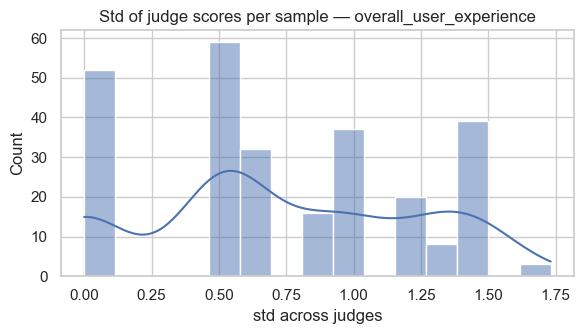

In [10]:
std_values = stats["std"]
print(std_values.describe())

plt.figure(figsize=(6, 3.5))
sns.histplot(std_values, bins=15, kde=True)
plt.title(f"Std of judge scores per sample — {DIMENSION}")
plt.xlabel("std across judges")
plt.tight_layout()
plt.show()


## Std across judges per dimension (all samples)
Summarize judge disagreement for every dimension; useful to spot which axes are most contentious.

                                  count      mean       50%       std  min  \
dimension                                                                    
commitment_consistency            265.0  0.650987  0.577350  0.512583  0.0   
initiative_timing                 265.0  0.732719  0.577350  0.467954  0.0   
intent_alignment_drift            262.0  0.599603  0.500000  0.452274  0.0   
interaction_coherence             265.0  0.622570  0.577350  0.372447  0.0   
interaction_efficiency            265.0  0.601635  0.577350  0.439507  0.0   
interaction_preference_alignment  266.0  0.911954  0.957427  0.575808  0.0   
overall_user_experience           266.0  0.729270  0.577350  0.495699  0.0   
user_cognitive_load_trajectory    262.0  0.701400  0.577350  0.477886  0.0   

                                       max  
dimension                                   
commitment_consistency            1.914854  
initiative_timing                 2.061553  
intent_alignment_drift            1.914

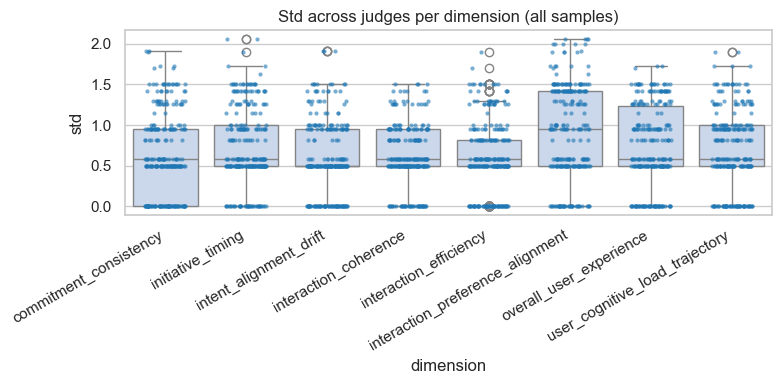

In [11]:
wide_all = df.pivot_table(index=["sample_key", "dimension"], columns="judge", values="score", aggfunc="first").dropna()
std_long = wide_all.std(axis=1).rename("std").reset_index()

summary = std_long.groupby("dimension")["std"].describe()[["count", "mean", "50%", "std", "min", "max"]]
print(summary)

plt.figure(figsize=(8, 4))
sns.boxplot(data=std_long, x="dimension", y="std", color="#c5d7f2")
sns.stripplot(data=std_long, x="dimension", y="std", color="#1f77b4", alpha=0.6, jitter=0.25, size=3)
plt.title("Std across judges per dimension (all samples)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


## ICC per dimension (all)
Compute ICC for each dimension separately (fixed judges), alongside other agreement stats per dimension.

In [12]:
icc_rows = []
for dim in sorted(df["dimension"].unique()):
    wide_dim = pivot_dimension(df, dim)
    if wide_dim.empty:
        continue
    icc_rows.append({
        "dimension": dim,
        "n_samples": wide_dim.shape[0],
        "icc_two_way_mixed": icc_two_way_mixed(wide_dim),
        "icc_oneway": icc_oneway(wide_dim),
        "cronbach_alpha": cronbach_alpha(wide_dim),
        "kendalls_w": kendalls_w(wide_dim),
    })

icc_df = pd.DataFrame(icc_rows)
print(icc_df)


                          dimension  n_samples  icc_two_way_mixed  icc_oneway  \
0            commitment_consistency        265           0.446192    0.376554   
1                 initiative_timing        265           0.499937    0.473521   
2            intent_alignment_drift        262           0.365364    0.284816   
3             interaction_coherence        265           0.600385    0.546110   
4            interaction_efficiency        265           0.621950    0.582681   
5  interaction_preference_alignment        266           0.497844    0.424734   
6           overall_user_experience        266           0.528568    0.470765   
7    user_cognitive_load_trajectory        262           0.572778    0.496457   

   cronbach_alpha  kendalls_w  
0        0.763186    0.433966  
1        0.799959    0.563130  
2        0.697229    0.341009  
3        0.857339    0.649074  
4        0.868085    0.642719  
5        0.798617    0.556126  
6        0.817678    0.587882  
7        0.842

## Agreement metrics (all dimensions)
Flatten all dimensions and samples, then compute Kendall's W, ICC(1,1), ICC(3,1) (fixed judges), and Cronbach's alpha across judges.

In [13]:
wide_all = df.pivot_table(index=["sample_key", "dimension"], columns="judge", values="score", aggfunc="first").dropna()
wide_all_z = df_z.pivot_table(index=["sample_key", "dimension"], columns="judge", values="score_z", aggfunc="first").dropna()

metrics_all = {
    "kendalls_w": kendalls_w(wide_all),
    "icc_oneway": icc_oneway(wide_all),
    "icc_two_way_mixed": icc_two_way_mixed(wide_all),
    "cronbach_alpha": cronbach_alpha(wide_all),
}
metrics_all_z = {
    "kendalls_w": kendalls_w(wide_all_z),
    "icc_oneway": icc_oneway(wide_all_z),
    "icc_two_way_mixed": icc_two_way_mixed(wide_all_z),
    "cronbach_alpha": cronbach_alpha(wide_all_z),
}
print(f"wide_all shape: {wide_all.shape}, z-scored shape: {wide_all_z.shape}")
print("Raw:", metrics_all)
print("Z-score:", metrics_all_z)


wide_all shape: (2116, 4), z-scored shape: (2116, 4)
Raw: {'kendalls_w': 0.6261512243445394, 'icc_oneway': 0.5371220895690737, 'icc_two_way_mixed': 0.5788552734170568, 'cronbach_alpha': 0.8461046602766202}
Z-score: {'kendalls_w': 0.6261512243445394, 'icc_oneway': 0.6028110000605138, 'icc_two_way_mixed': 0.6026804409626189, 'cronbach_alpha': 0.8585065127785338}


## Pick samples to visualize
By default prints the first N samples (sorted). Override with `SAMPLE_KEYS_OVERRIDE` or `SAMPLE_INDEX` to inspect a specific sample.

In [14]:
selected_keys = []
if SAMPLE_KEYS_OVERRIDE:
    selected_keys = [k for k in SAMPLE_KEYS_OVERRIDE if k in sample_keys]
elif SAMPLE_INDEX is not None:
    if 0 <= SAMPLE_INDEX < len(sample_keys):
        selected_keys = [sample_keys[SAMPLE_INDEX]]
    else:
        raise IndexError(f"SAMPLE_INDEX {SAMPLE_INDEX} out of range (0-{len(sample_keys)-1})")
else:
    selected_keys = sample_keys[:MAX_SAMPLE_PLOTS]

print(f"Will plot {len(selected_keys)} samples: {selected_keys[:MAX_SAMPLE_PLOTS]}")


Will plot 1 samples: ['chain_parallel/multi_turn_long_context_101']


## Scatter + centroid (per-sample)
Polar-ish scatter of each judge score for a sample; centroid shows agreement tightness.

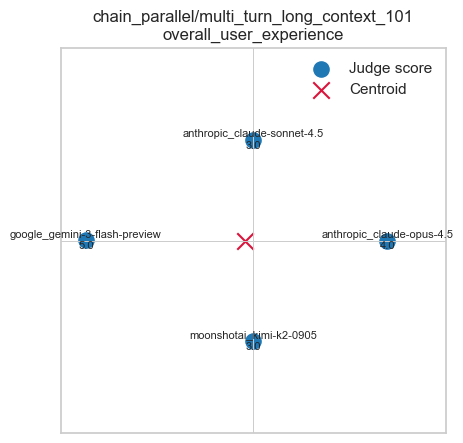

In [15]:
for key in selected_keys[:MAX_SAMPLE_PLOTS]:
    fig, ax = plt.subplots(figsize=(5, 5))
    plot_radial_scatter(key, wide.loc[key], DIMENSION, ax=ax)
    plt.show()


## Agreement heatmap
Correlation between judges across all samples for the selected dimension.

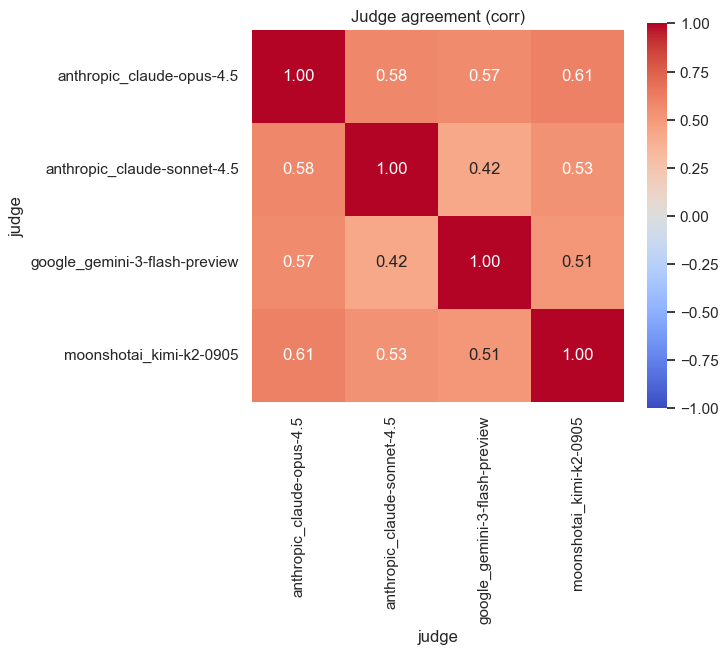

In [18]:
# for dim in df["dimension"].unique():
#     corr = df[df["dimension"] == dim].pivot(index="sample_key", columns="judge", values="score").corr()
#     plt.figure(figsize=(5, 4))
#     sns.heatmap(corr, annot=True, fmt=".2f", vmin=-1, vmax=1, cmap="coolwarm", square=True)
#     plt.title(f"Judge agreement (corr) on {dim}")
#     plt.show()

dimensions = df["dimension"].unique()
judge_list = df["judge"].unique()
# Used to accumulate correlation matrices
corr_sum = None
count = 0

for dim in dimensions:
    corr = df[df["dimension"] == dim].pivot(index="sample_key", columns="judge", values="score").corr()
    # Fill missing judges with NaN to keep dimension/judge order consistent
    corr = corr.reindex(index=judge_list, columns=judge_list)
    if corr_sum is None:
        corr_sum = corr.fillna(0)
    else:
        corr_sum = corr_sum.add(corr.fillna(0), fill_value=0)
    count += 1

# Mean
corr_avg = corr_sum / count

plt.figure(figsize=(6, 5))
sns.heatmap(corr_avg, annot=True, fmt=".2f", vmin=-1, vmax=1, cmap="coolwarm", square=True)
plt.title("Judge agreement (corr)")
plt.show()


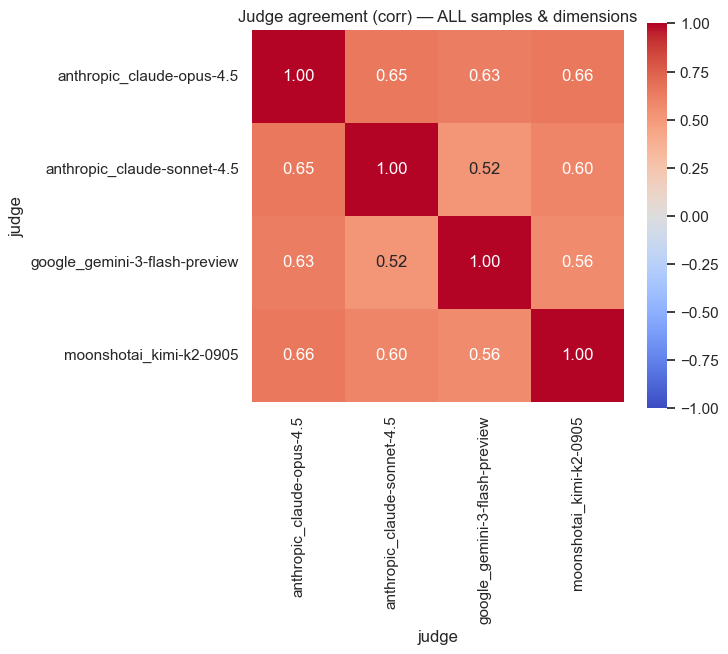

In [17]:
wide_all = df.pivot_table(index=["sample_key", "dimension"], columns="judge", values="score", aggfunc="first")
corr_global = wide_all.corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr_global, annot=True, fmt=".2f", vmin=-1, vmax=1, cmap="coolwarm", square=True)
plt.title("Judge agreement (corr) — ALL samples & dimensions")
plt.show()

